# Exploração de Dados Públicos Brasileiros

Este notebook realiza a análise exploratória dos dados coletados via pipeline de dados públicos.

## Fontes de Dados
- **IBGE**: Indicadores sociodemográficos e econômicos
- **Receita Federal**: Dados cadastrais de empresas (CNPJ)

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Configuração de caminhos
DATA_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Exploração de Dados IBGE

In [2]:
# Carregar dados de estados (processed primeiro, raw como fallback)
estados_parquet = PROCESSED_DIR / 'estados'
estados_path = DATA_DIR / 'ibge' / 'estados.json'
if estados_parquet.exists():
    df_estados = pd.read_parquet(estados_parquet)
    print(f'Total de estados (processed): {len(df_estados)}')
elif estados_path.exists():
    df_estados = pd.read_json(estados_path)
    print(f'Total de estados (raw): {len(df_estados)}')
else:
    raise FileNotFoundError('Execute o coletor (src.collectors.ibge_collector) ou o transformer primeiro.')
df_estados.head(10)

Total de estados (processed): 27


,id,sigla,nome,regiao_id,regiao_sigla,regiao_nome
0,11,RO,Rondônia,1,N,Norte
1,12,AC,Acre,1,N,Norte
2,13,AM,Amazonas,1,N,Norte
3,14,RR,Roraima,1,N,Norte
4,15,PA,Pará,1,N,Norte
5,16,AP,Amapá,1,N,Norte
6,17,TO,Tocantins,1,N,Norte
7,21,MA,Maranhão,2,NE,Nordeste
8,22,PI,Piauí,2,NE,Nordeste
9,23,CE,Ceará,2,NE,Nordeste


In [3]:
# Carregar dados de municípios (processed primeiro, raw como fallback).
# O JSON raw é aninhado (microrregiao.mesorregiao.UF...), então sem
# json_normalize as colunas 'sigla_uf'/'regiao_nome' não existem.
municipios_parquet = PROCESSED_DIR / 'municipios'
municipios_path = DATA_DIR / 'ibge' / 'municipios.json'
if municipios_parquet.exists():
    df_municipios = pd.read_parquet(municipios_parquet)
    print(f'Total de municípios (processed): {len(df_municipios)}')
elif municipios_path.exists():
    df_municipios = pd.json_normalize(pd.read_json(municipios_path).to_dict(orient='records'))
    df_municipios = df_municipios.rename(columns={
        'microrregiao.mesorregiao.UF.sigla': 'sigla_uf',
        'microrregiao.mesorregiao.UF.regiao.nome': 'regiao_nome',
    })
    print(f'Total de municípios (raw normalizado): {len(df_municipios)}')
else:
    raise FileNotFoundError('Execute o coletor (src.collectors.ibge_collector) ou o transformer primeiro.')
print(f'\nColunas disponíveis: {list(df_municipios.columns)}')
df_municipios.head()

Total de municípios (processed): 5571

Colunas disponíveis: ['id', 'nome', 'sigla_uf', 'uf_id', 'uf_nome', 'regiao_id', 'regiao_sigla', 'regiao_nome', 'mesorregiao_id', 'mesorregiao_nome', 'microrregiao_id', 'microrregiao_nome', 'regiao_imediata_id', 'regiao_imediata_nome', 'regiao_intermediaria_id', 'regiao_intermediaria_nome']


,id,nome,sigla_uf,uf_id,uf_nome,regiao_id,regiao_sigla,regiao_nome,mesorregiao_id,mesorregiao_nome,microrregiao_id,microrregiao_nome,regiao_imediata_id,regiao_imediata_nome,regiao_intermediaria_id,regiao_intermediaria_nome
0,5200050,Abadia De Goiás,GO,52.0,Goiás,5.0,CO,Centro-oeste,5203.0,Centro Goiano,52010.0,Goiânia,520001,Goiânia,NaN,NaN
1,3100104,Abadia Dos Dourados,MG,31.0,Minas Gerais,3.0,SE,Sudeste,3105.0,Triângulo Mineiro/alto Paranaíba,31019.0,Patrocínio,310061,Monte Carmelo,NaN,NaN
2,5200100,Abadiânia,GO,52.0,Goiás,5.0,CO,Centro-oeste,5204.0,Leste Goiano,52012.0,Entorno De Brasília,520002,Anápolis,NaN,NaN
3,1500107,Abaetetuba,PA,15.0,Pará,1.0,N,Norte,1504.0,Nordeste Paraense,15011.0,Cametá,150003,Abaetetuba,NaN,NaN
4,3100203,Abaeté,MG,31.0,Minas Gerais,3.0,SE,Sudeste,3106.0,Central Mineira,31024.0,Três Marias,310070,Abaeté,NaN,NaN


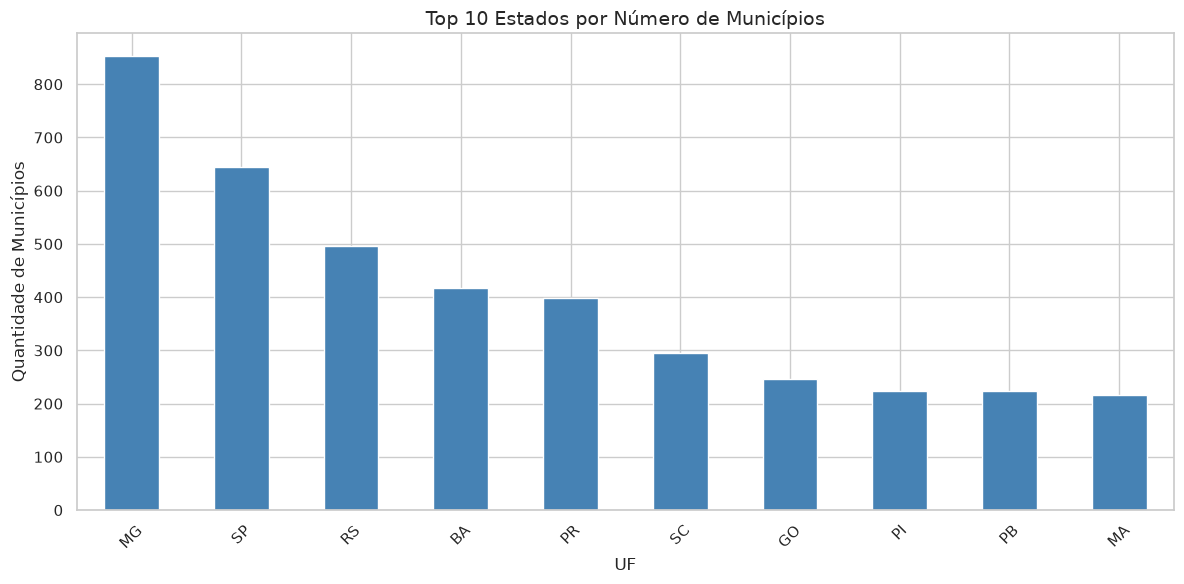


Estatísticas por estado:
count     10.000000
mean     401.600000
std      212.247863
min      217.000000
25%      229.500000
50%      347.000000
75%      477.000000
max      853.000000
Name: count, dtype: float64


In [4]:
# Distribuição de municípios por estado
col_uf = 'sigla_uf' if 'sigla_uf' in df_municipios.columns else 'sigla'
assert col_uf in df_municipios.columns, f"Coluna de UF ausente. Colunas: {list(df_municipios.columns)}"
contagem_uf = df_municipios[col_uf].value_counts().head(10)
        
fig, ax = plt.subplots(figsize=(12, 6))
contagem_uf.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 Estados por Número de Municípios', fontsize=14)
ax.set_xlabel('UF')
ax.set_ylabel('Quantidade de Municípios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
        
print(f'\nEstatísticas por estado:')
print(contagem_uf.describe())

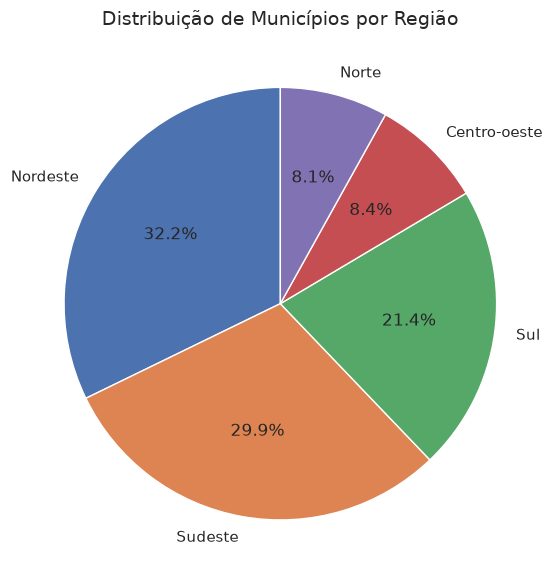

In [5]:
# Análise de municípios por região
col_regiao = 'regiao_nome' if 'regiao_nome' in df_municipios.columns else 'regiao-nome'
assert col_regiao in df_municipios.columns, f"Coluna de região ausente. Colunas: {list(df_municipios.columns)}"
contagem_regiao = df_municipios[col_regiao].value_counts()
    
fig, ax = plt.subplots(figsize=(10, 6))
contagem_regiao.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
ax.set_title('Distribuição de Municípios por Região', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 2. Exploração de Dados de CNPJ

In [6]:
# Carregar dados de CNPJs (processed primeiro, raw como fallback)
import glob

cnpjs_parquet = PROCESSED_DIR / 'cnpjs'
arquivos_cnpj = sorted(glob.glob(str(DATA_DIR / 'cnpj' / 'cnpjs_*.json')))
if cnpjs_parquet.exists():
    df_cnpjs = pd.read_parquet(cnpjs_parquet)
    print(f'Total de CNPJs (processed): {len(df_cnpjs)}')
elif arquivos_cnpj:
    arquivo_mais_recente = arquivos_cnpj[-1]
    print(f'Carregando arquivo: {Path(arquivo_mais_recente).name}')
    df_cnpjs = pd.read_json(arquivo_mais_recente)
    print(f'Total de CNPJs consultados: {len(df_cnpjs)}')
else:
    raise FileNotFoundError('Execute o coletor (src.collectors.cnpj_collector) ou o transformer primeiro.')
print(f'\nColunas: {list(df_cnpjs.columns)}')
df_cnpjs.head()

Total de CNPJs (processed): 2

Colunas: ['atividade_principal', 'atividades_secundarias', 'bairro', 'capital_social', 'cep', 'cnpj', 'complemento', 'data_abertura', 'data_situacao_cadastral', 'email', 'logradouro', 'motivo_situacao_cadastral', 'municipio', 'natureza_juridica', 'nome_fantasia', 'numero', 'porte', 'razao_social', 'situacao_cadastral', 'socios', 'telefone1', 'telefone2', 'tipo_juridico', 'uf', 'ultima_atualizacao', 'eh_ativa']


,atividade_principal,atividades_secundarias,bairro,capital_social,cep,cnpj,complemento,data_abertura,data_situacao_cadastral,email,...,porte,razao_social,situacao_cadastral,socios,telefone1,telefone2,tipo_juridico,uf,ultima_atualizacao,eh_ativa
0,"Bancos múltiplos, com carteira comercial","[""Outras atividades de serviços financeiros nã...",ASA NORTE,1.200000e+11,70040912,00000000000191,ANDAR T I SL S101 A S1602 T II SL C101 A C1602...,1966-08-01,None,secex@bb.com.br,...,DEMAIS,Banco Do Brasil Sa,ATIVA,"[""FELIPE GUIMARAES GEISSLER PRINCE"", ""ROSIANE ...",,,MATRIZ,DF,2026-09-26T14:17:07.177Z,True
1,Caixas econômicas,"[""Não informada""]",ASA SUL,1.126000e+11,70092900,00360305000104,QUADRA4 BLOCO A ANDAR TODOS,1971-02-03,None,,...,DEMAIS,Caixa Economica Federal,ATIVA,"[""MARCOS BRASILIANO ROSA"", ""INES DA SILVA MAGA...",,,MATRIZ,DF,2026-09-25T11:57:33.514Z,True


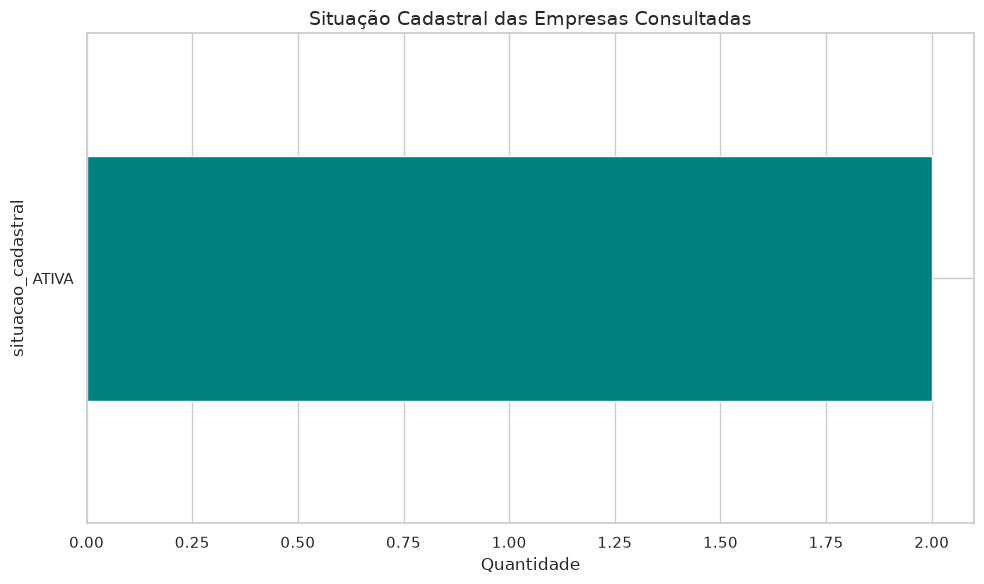

In [7]:
# Análise de situação cadastral
assert 'situacao_cadastral' in df_cnpjs.columns, f"Coluna 'situacao_cadastral' ausente. Colunas: {list(df_cnpjs.columns)}"
contagem_situacao = df_cnpjs['situacao_cadastral'].value_counts()
    
fig, ax = plt.subplots(figsize=(10, 6))
contagem_situacao.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Situação Cadastral das Empresas Consultadas', fontsize=14)
ax.set_xlabel('Quantidade')
plt.tight_layout()
plt.show()

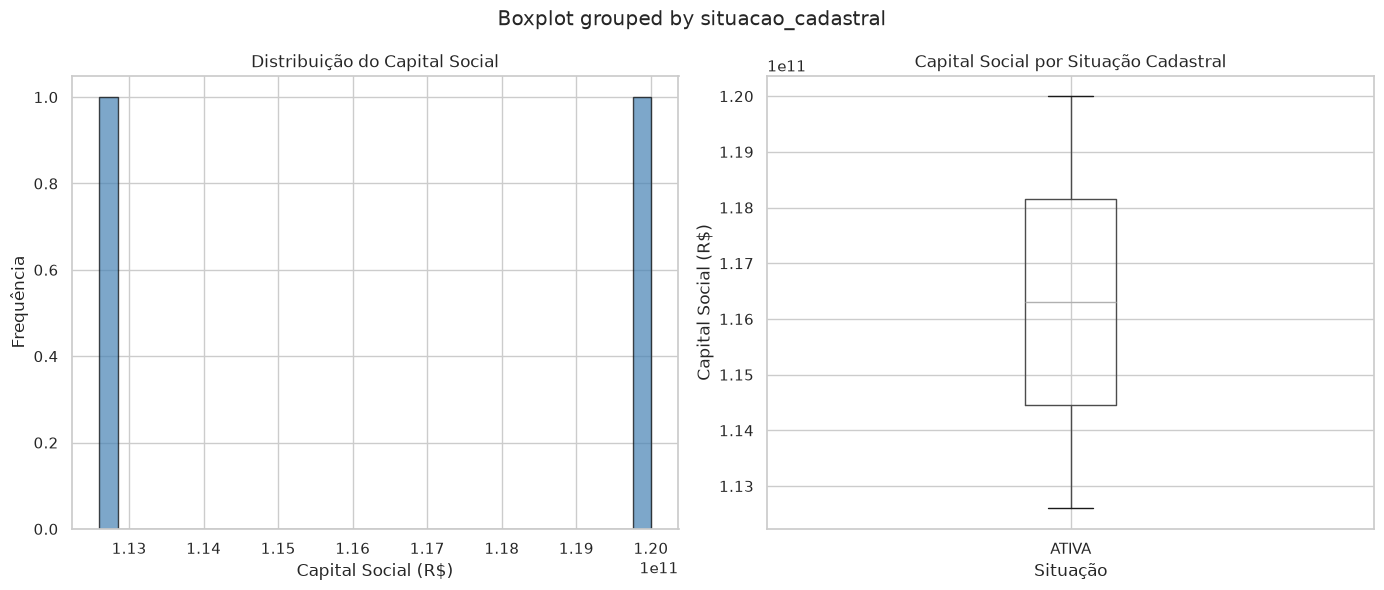


Estatísticas do Capital Social:
  Média: R$ 116,300,000,000.00
  Mediana: R$ 116,300,000,000.00
  Máximo: R$ 120,000,000,000.00
  Mínimo: R$ 112,600,000,000.00


In [8]:
# Análise de capital social
assert 'capital_social' in df_cnpjs.columns, f"Coluna 'capital_social' ausente. Colunas: {list(df_cnpjs.columns)}"
capital = pd.to_numeric(df_cnpjs['capital_social'], errors='coerce').dropna()
capital = capital[capital > 0]
    
if len(capital) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
    # Histograma do capital social
    axes[0].hist(capital, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribuição do Capital Social', fontsize=12)
    axes[0].set_xlabel('Capital Social (R$)')
    axes[0].set_ylabel('Frequência')
        
    # Boxplot por situação cadastral
    if 'situacao_cadastral' in df_cnpjs.columns:
        df_temp = df_cnpjs.copy()
        df_temp['capital_social_num'] = pd.to_numeric(df_temp['capital_social'], errors='coerce')
        df_temp = df_temp.dropna(subset=['capital_social_num'])
        df_temp = df_temp[df_temp['capital_social_num'] > 0]
            
        if len(df_temp) > 0:
            df_temp.boxplot(column='capital_social_num', by='situacao_cadastral', ax=axes[1])
            axes[1].set_title('Capital Social por Situação Cadastral', fontsize=12)
            axes[1].set_xlabel('Situação')
            axes[1].set_ylabel('Capital Social (R$)')
        
    plt.tight_layout()
    plt.show()
        
    print(f'\nEstatísticas do Capital Social:')
    print(f'  Média: R$ {capital.mean():,.2f}')
    print(f'  Mediana: R$ {capital.median():,.2f}')
    print(f'  Máximo: R$ {capital.max():,.2f}')
    print(f'  Mínimo: R$ {capital.min():,.2f}')
else:
    print('Sem valores de capital social > 0 para analisar.')

## 3. Análise de Atividades Econômicas (CNAE)

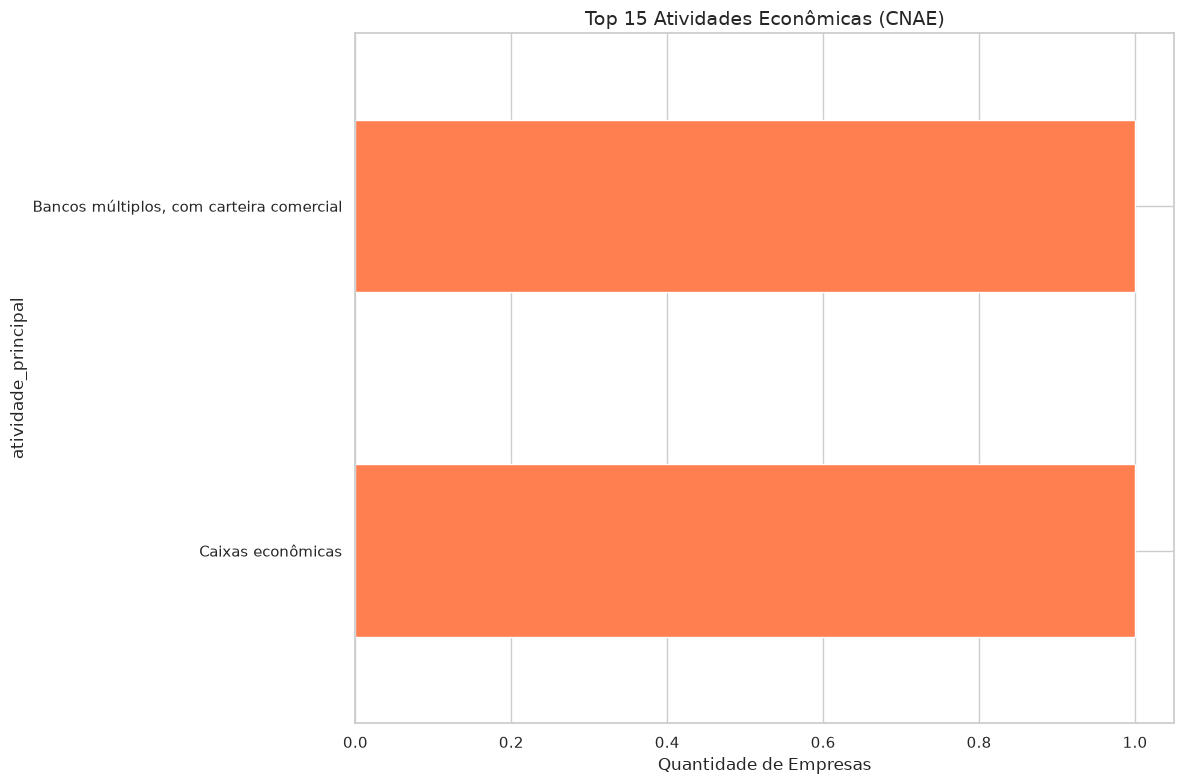

In [9]:
# Top atividades principais
assert 'atividade_principal' in df_cnpjs.columns, f"Coluna 'atividade_principal' ausente. Colunas: {list(df_cnpjs.columns)}"
atividades = df_cnpjs['atividade_principal'].value_counts().head(15)
    
if len(atividades) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    atividades.plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Top 15 Atividades Econômicas (CNAE)', fontsize=14)
    ax.set_xlabel('Quantidade de Empresas')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Sem atividades principais para analisar.')

## 4. Análise Geográfica

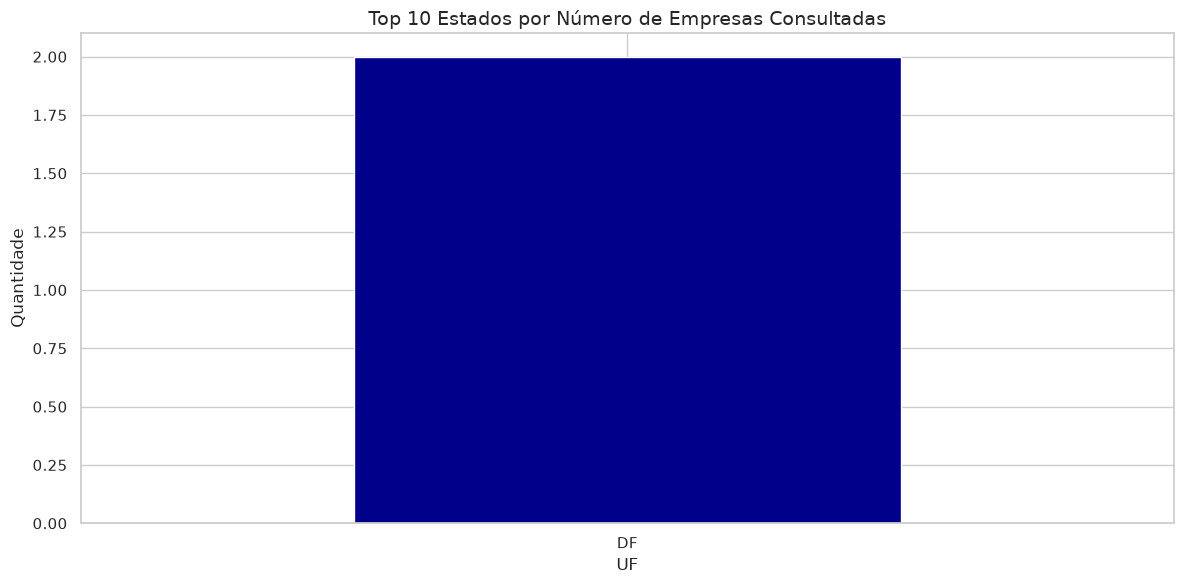

In [10]:
# Empresas por estado
assert 'uf' in df_cnpjs.columns, f"Coluna 'uf' ausente. Colunas: {list(df_cnpjs.columns)}"
empresas_por_uf = df_cnpjs['uf'].value_counts().head(10)
    
fig, ax = plt.subplots(figsize=(12, 6))
empresas_por_uf.plot(kind='bar', ax=ax, color='darkblue')
ax.set_title('Top 10 Estados por Número de Empresas Consultadas', fontsize=14)
ax.set_xlabel('UF')
ax.set_ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

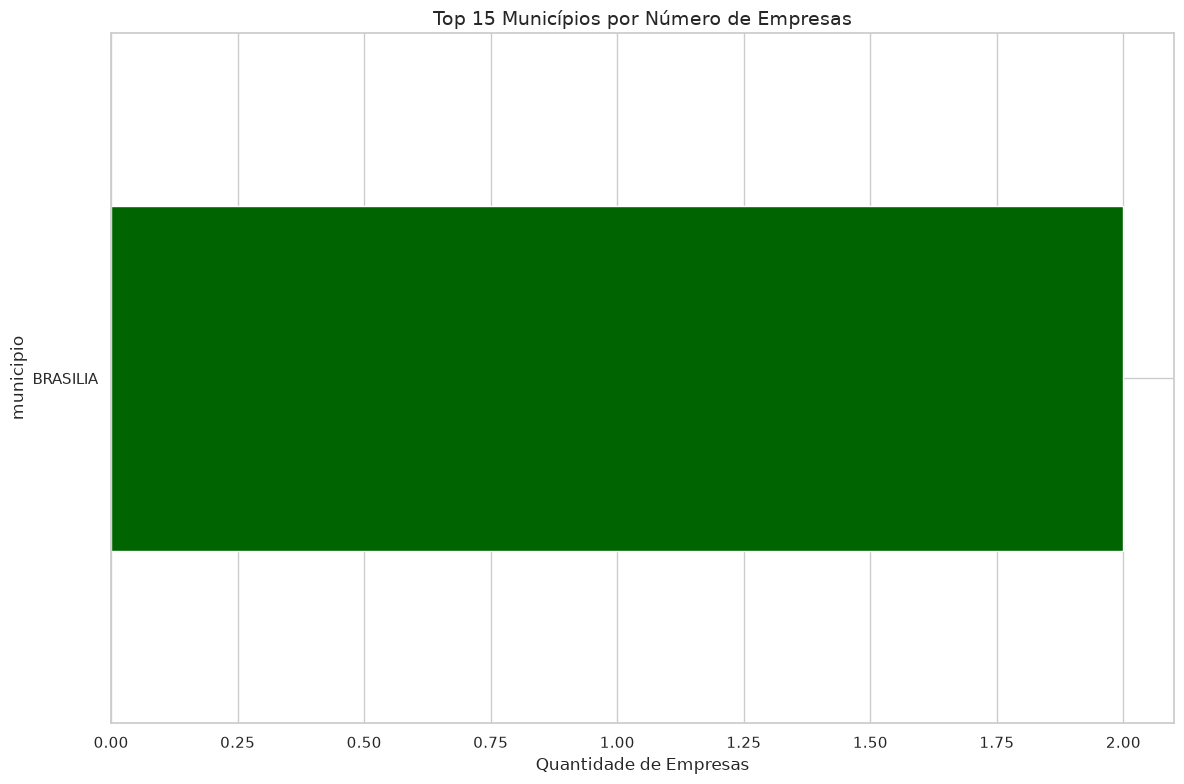

In [11]:
# Municípios com mais empresas (top 15)
assert 'municipio' in df_cnpjs.columns, f"Coluna 'municipio' ausente. Colunas: {list(df_cnpjs.columns)}"
top_municipios = df_cnpjs['municipio'].value_counts().head(15)
    
fig, ax = plt.subplots(figsize=(12, 8))
top_municipios.plot(kind='barh', ax=ax, color='darkgreen')
ax.set_title('Top 15 Municípios por Número de Empresas', fontsize=14)
ax.set_xlabel('Quantidade de Empresas')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Resumo dos Dados Coletados

In [12]:
# Resumo geral
print('=' * 60)
print('RESUMO DOS DADOS PÚBLICOS COLETADOS')
print('=' * 60)

print(f'\n📊 IBGE:')
print(f'   Estados: {len(df_estados)}')
print(f'   Municípios: {len(df_municipios)}')
col_uf = 'sigla_uf' if 'sigla_uf' in df_municipios.columns else 'sigla'
assert col_uf in df_municipios.columns, f"Coluna de UF ausente. Colunas: {list(df_municipios.columns)}"
print(f'   Estados com municípios: {df_municipios[col_uf].nunique()}')

print(f'\n🏢 CNPJ:')
print(f'   Empresas consultadas: {len(df_cnpjs)}')
if 'situacao_cadastral' in df_cnpjs.columns:
    ativas = df_cnpjs[df_cnpjs['situacao_cadastral'] == 'ATIVA'].shape[0]
    print(f'   Empresas ativas: {ativas}')
if 'uf' in df_cnpjs.columns:
    print(f'   Estados representados: {df_cnpjs["uf"].nunique()}')

print(f'\n{'=' * 60}')

RESUMO DOS DADOS PÚBLICOS COLETADOS

📊 IBGE:
   Estados: 27
   Municípios: 5571
   Estados com municípios: 27

🏢 CNPJ:
   Empresas consultadas: 2
   Empresas ativas: 2
   Estados representados: 1

